In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('.././data_thuydien/dataCacDap/data_thuydien_Sông_Ba_Hạ.csv')
df.head()

,ten_ho,thoi_diem,muc_nuoc_thuong_luu_m,muc_nuoc_dang_binh_thuong_m,muc_nuoc_chet_m,luu_luong_den_ho_m3_s,tong_luong_xa_m3_s,tong_luong_xa_qua_dap_tran_m3_s,tong_luong_xa_qua_nha_may_m3_s,so_cua_xa_sau,so_cua_xa_mat
0,Sông Ba Hạ,2022-01-01 00:00:00,104.94,105,101,410.0,450.0,50.0,400.0,0,1
1,Sông Ba Hạ,2022-01-01 01:00:00,104.93,105,101,405.0,450.0,50.0,400.0,0,1
2,Sông Ba Hạ,2022-01-01 02:00:00,104.93,105,101,415.0,450.0,50.0,400.0,0,1
3,Sông Ba Hạ,2022-01-01 03:00:00,104.92,105,101,420.0,450.0,50.0,400.0,0,1
4,Sông Ba Hạ,2022-01-01 04:00:00,104.92,105,101,425.0,450.0,50.0,400.0,0,1


# Step1: Loại bỏ một số cột không cần thiết

In [3]:
cols_to_drop = [
    "muc_nuoc_dang_binh_thuong_m",
    "muc_nuoc_chet_m",
    "so_cua_xa_sau",
    "so_cua_xa_mat",
]

missing = [c for c in cols_to_drop if c not in df.columns]
if missing:
    print("Cột không tìm thấy (bỏ qua khi xoá):", missing)


In [5]:
before_shape = df.shape
before_cols = set(df.columns)

df = df.drop(columns=cols_to_drop, errors="ignore")

after_shape = df.shape
dropped_effective = list(before_cols - set(df.columns))

print("ĐÃ XOÁ:", dropped_effective)
print("Shape trước -> sau:", before_shape, "->", after_shape)
print("Còn lại các cột:", list(df.columns))

df.to_csv(".././data_thuydien_preprocessed/data_thuydien_SongBaHa_preprocessed_step1.csv", index=False, encoding="utf-8")


ĐÃ XOÁ: []
Shape trước -> sau: (34343, 7) -> (34343, 7)
Còn lại các cột: ['ten_ho', 'thoi_diem', 'muc_nuoc_thuong_luu_m', 'luu_luong_den_ho_m3_s', 'tong_luong_xa_m3_s', 'tong_luong_xa_qua_dap_tran_m3_s', 'tong_luong_xa_qua_nha_may_m3_s']


# Xử lý

## Xử lý outlier của trường thông tin `muc_nuoc_thuong_luu_m`, chú trọng việc xử lý theo từng tháng

In [6]:
df = pd.read_csv('.././data_thuydien_preprocessed/data_thuydien_SongBaHa_preprocessed_step1.csv')

In [7]:
import pandas as pd
import numpy as np

time_col   = "thoi_diem"
target_col = "muc_nuoc_thuong_luu_m"

# Ép datetime an toàn
df[time_col] = (
    pd.to_datetime(df[time_col], errors="coerce", infer_datetime_format=True)
)

# Thử format cố định nếu còn NaT
if df[time_col].isna().any():
    s2 = pd.to_datetime(df[time_col].astype(str), errors="coerce", format="%Y-%m-%d %H:%M:%S")
    df[time_col] = df[time_col].fillna(s2)

assert df[time_col].notna().all(), "Còn NaT ở thoi_diem — cần làm sạch trước."
df[target_col] = pd.to_numeric(df[target_col], errors="raise")

# Khóa nhóm
df["year"]  = df[time_col].dt.year
df["month"] = df[time_col].dt.month


C:\Users\Admin\AppData\Local\Temp\ipykernel_19360\540051599.py:9: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  pd.to_datetime(df[time_col], errors="coerce", infer_datetime_format=True)


In [8]:
from IPython.display import display

# Chọn phạm vi năm cần xử lý (đổi nếu chỉ muốn 2022–2024)
years_to_fix = sorted(df["year"].unique())   # ví dụ: [2022, 2023, 2024]
mask_years   = df["year"].isin(years_to_fix)

# Làm việc trên subset theo năm cần xử lý
sub = df.loc[mask_years, [time_col, "year", "month", target_col]].copy()

# Tính Q1/Q3 theo (year, month)
gb = sub.groupby(["year","month"])[target_col]
sub["Q1"] = gb.transform(lambda s: s.quantile(0.25))
sub["Q3"] = gb.transform(lambda s: s.quantile(0.75))
sub["IQR"] = sub["Q3"] - sub["Q1"]
sub["LB"]  = sub["Q1"] - 1.5*sub["IQR"]
sub["UB"]  = sub["Q3"] + 1.5*sub["IQR"]

# Đánh dấu outlier theo (year, month)
sub["is_out"] = (sub[target_col] < sub["LB"]) | (sub[target_col] > sub["UB"])

# Tóm tắt theo (year, month)
month_summary = (sub.groupby(["year","month"], as_index=False)
                   .agg(n=(target_col, "size"),
                        n_out=("is_out", "sum"),
                        LB=("LB", "first"),
                        UB=("UB", "first"))
                   .sort_values(["year","month"]))
display(month_summary)

# Các (năm, tháng) cần xử lý (có ít nhất 1 outlier)
pairs_to_fix = set(map(tuple, month_summary.loc[month_summary["n_out"]>0, ["year","month"]].values.tolist()))
print("Các (năm, tháng) sẽ được xử lý:", sorted(pairs_to_fix))


,year,month,n,n_out,LB,UB
0,2022,1,744,0,103.84625,104.97625
1,2022,2,672,0,103.55500,104.63500
2,2022,3,744,0,102.50000,104.90000
3,2022,4,720,0,102.68000,103.88000
4,2022,5,744,0,101.74000,105.26000
5,2022,6,720,0,101.82500,104.74500
6,2022,7,744,0,101.12500,103.88500
7,2022,8,744,0,98.37375,108.38375
8,2022,9,720,8,102.15500,103.39500
9,2022,10,744,137,102.55875,103.16875


Các (năm, tháng) sẽ được xử lý: [(2022, 9), (2022, 10), (2023, 1), (2023, 10), (2023, 12), (2024, 1), (2024, 4), (2024, 5), (2024, 7), (2024, 8), (2024, 9), (2024, 10), (2025, 4), (2025, 9), (2025, 10)]


In [9]:
# Cờ "tháng–năm thuộc danh sách cần xử lý"
apply_mask = sub[["year","month"]].apply(tuple, axis=1).isin(pairs_to_fix)

# Mask outlier cần fill
mask_out = apply_mask & ((sub[target_col] < sub["LB"]) | (sub[target_col] > sub["UB"]))

# Fill: <LB -> LB, >UB -> UB (theo từng hàng, đã có LB/UB riêng của (year,month))
filled = sub[target_col].where(sub[target_col] >= sub["LB"], sub["LB"])
filled = filled.where(filled <= sub["UB"], sub["UB"])
sub["filled"] = sub[target_col]
sub.loc[mask_out, "filled"] = filled.loc[mask_out]

# Gộp về df gốc theo index
df["muc_nuoc_thuong_luu_m_filled"] = df[target_col]
df.loc[sub.index, "muc_nuoc_thuong_luu_m_filled"] = sub["filled"].values

# Kiểm chứng sau fill: còn ai vượt LB/UB trong các (năm,tháng) đã xử lý?
chk = sub.copy()
chk["after"] = chk["filled"]
viol = chk[apply_mask & ((chk["after"] < chk["LB"]) | (chk["after"] > chk["UB"]))]
print("Số điểm còn vi phạm sau fill (kỳ vọng 0):", len(viol))

# Thống kê số điểm đã fill theo (year, month)
changed = (sub["filled"] != sub[target_col])
cap_stats = (pd.DataFrame({"year": sub["year"], "month": sub["month"], "changed": changed})
             .groupby(["year","month"], as_index=False)
             .agg(changed=("changed","sum")))
cap_stats = cap_stats.merge(month_summary[["year","month","n"]], on=["year","month"], how="left")
cap_stats["changed_pct"] = (100.0 * cap_stats["changed"] / cap_stats["n"]).round(2)
display(cap_stats.sort_values(["year","month"]))
print("Tổng số điểm đã fill:", int(cap_stats["changed"].sum()))


Số điểm còn vi phạm sau fill (kỳ vọng 0): 0


,year,month,changed,n,changed_pct
0,2022,1,0,744,0.00
1,2022,2,0,672,0.00
2,2022,3,0,744,0.00
3,2022,4,0,720,0.00
4,2022,5,0,744,0.00
5,2022,6,0,720,0.00
6,2022,7,0,744,0.00
7,2022,8,0,744,0.00
8,2022,9,8,720,1.11
9,2022,10,137,744,18.41


Tổng số điểm đã fill: 883


In [10]:
from pathlib import Path

OUT_PATH = Path(".././data_thuydien_preprocessed/data_thuydien_SongBaHa_preprocessed_step2.csv")
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df_out = df.drop(columns=["year","month"])  # gọn
df_out.to_csv(OUT_PATH, index=False, encoding="utf-8")
print("✅ Đã lưu:", OUT_PATH.resolve())


✅ Đã lưu: C:\Users\Admin\OneDrive\A01. Giáo trình UIT\C01. HKI-2025-2026\Khai thác dữ liệu và ứng dụng - CS313.Q12\DoAn\CuoiKi\data_thuydien_preprocessed\data_thuydien_SongBaHa_preprocessed_step2.csv


Kiểm tra sau khi xử lý

out_dir = "./data_thuydien/plots_preprocessed/"

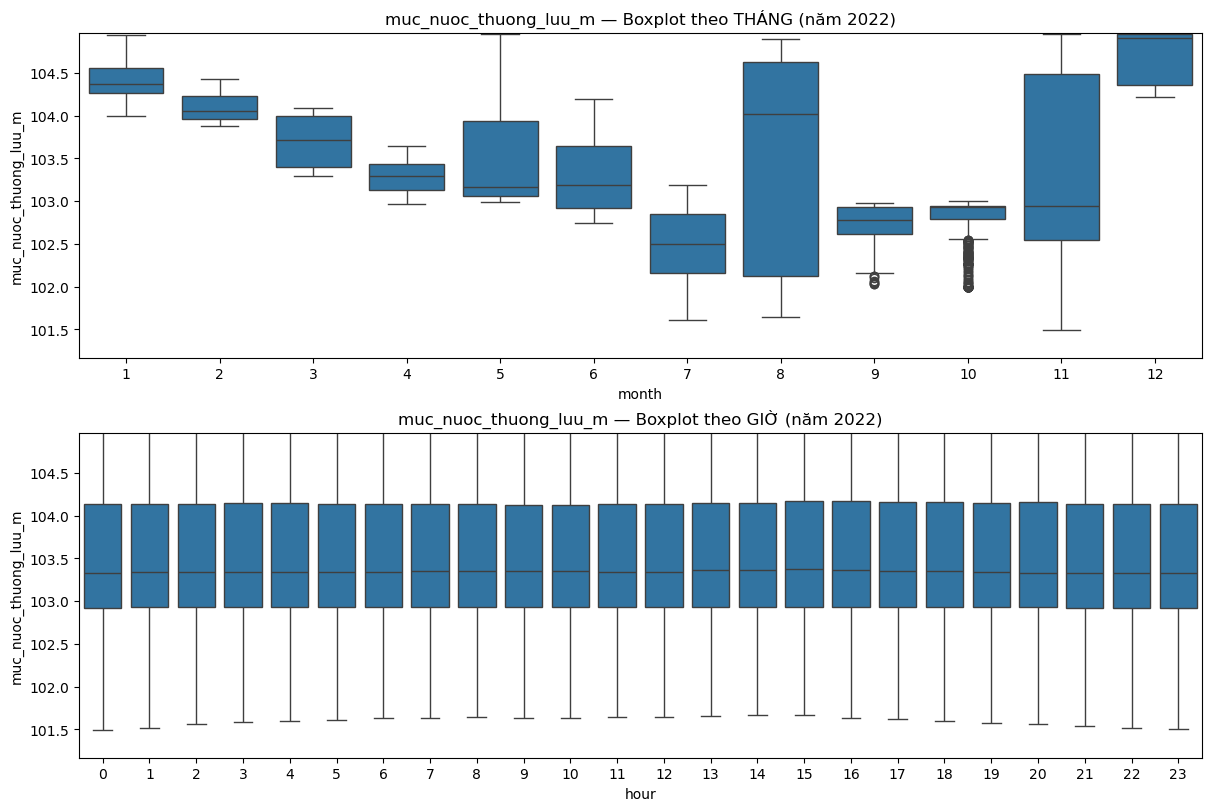

Saved: ./plots_preprocessed/muc_nuoc_thuong_luu_m_box_month_hour_2022.png


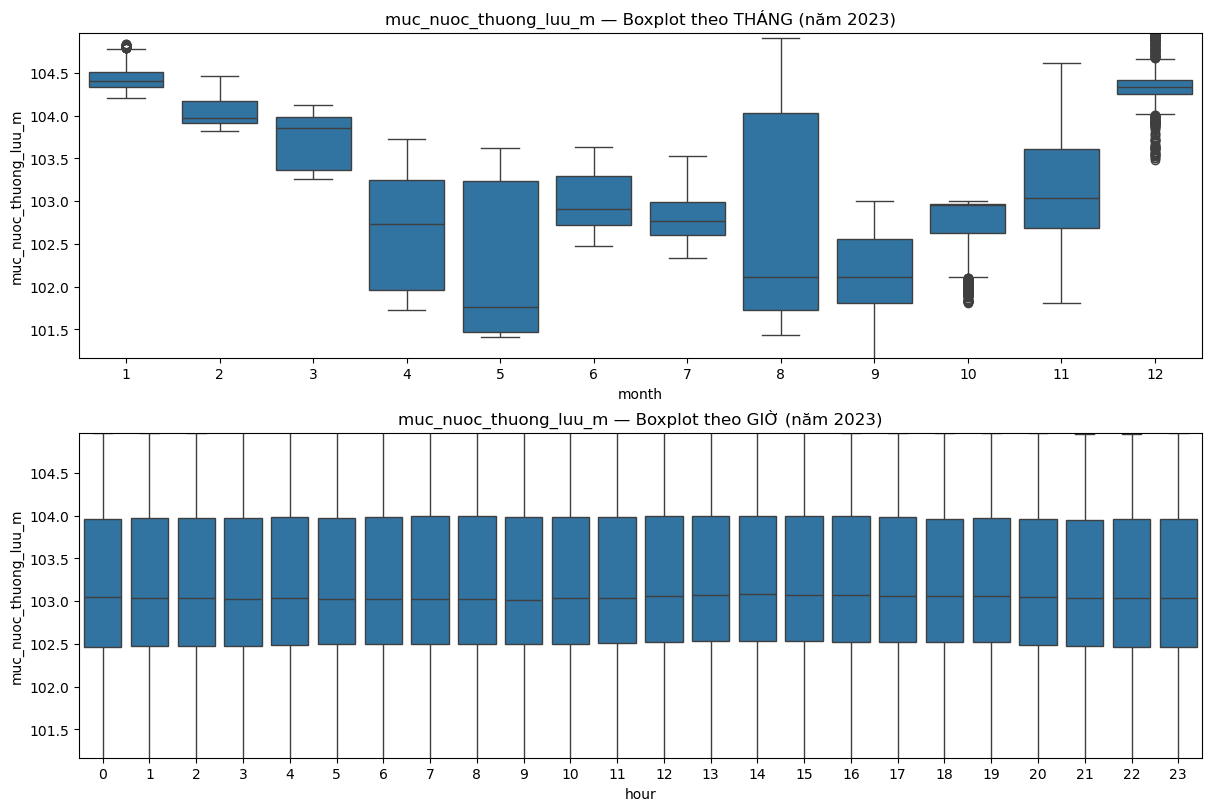

Saved: ./plots_preprocessed/muc_nuoc_thuong_luu_m_box_month_hour_2023.png


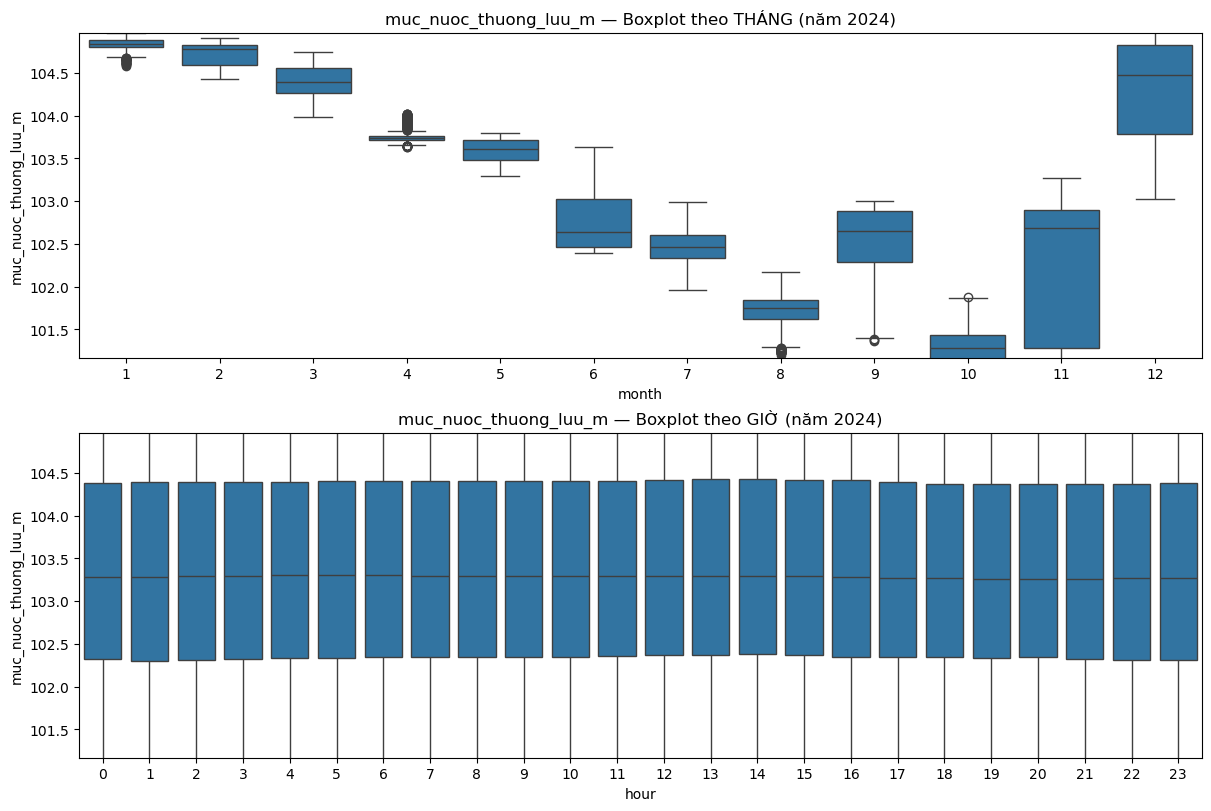

Saved: ./plots_preprocessed/muc_nuoc_thuong_luu_m_box_month_hour_2024.png


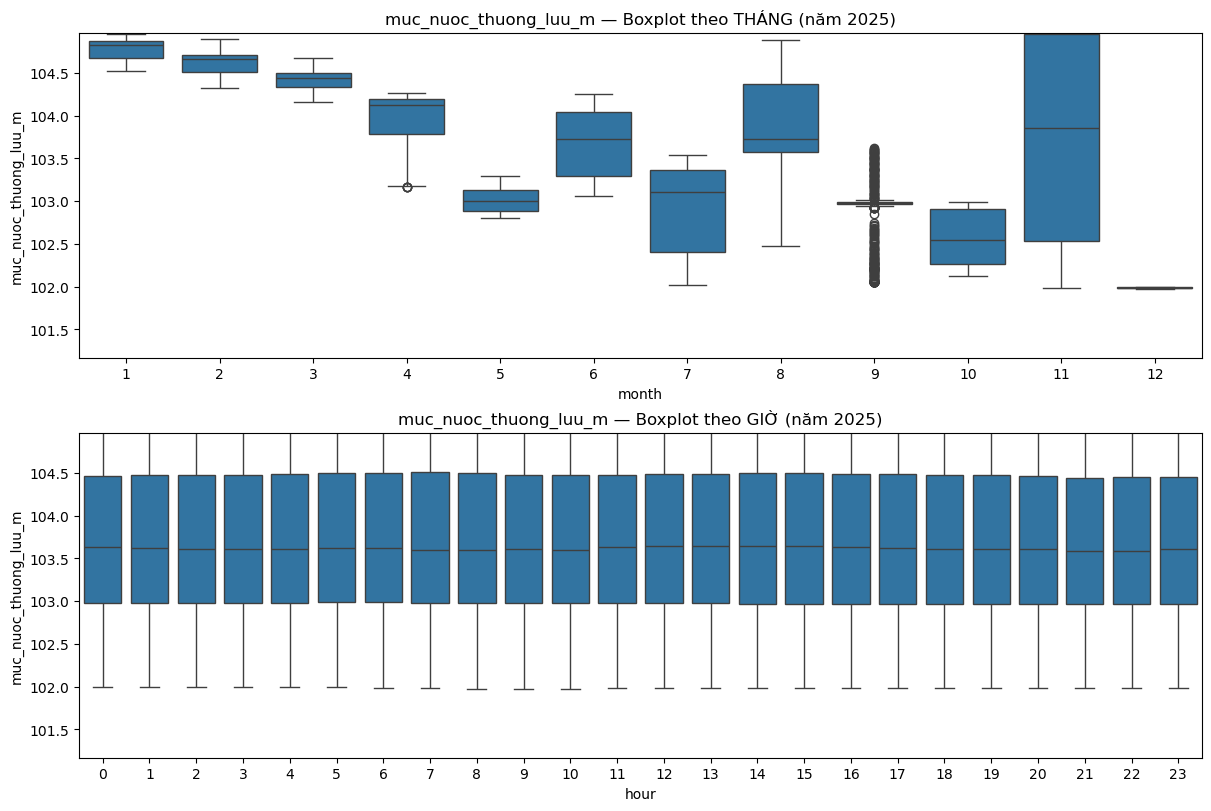

Saved: ./plots_preprocessed/muc_nuoc_thuong_luu_m_box_month_hour_2025.png


In [11]:
import os
import seaborn as sns
import matplotlib.pyplot as plt

df_out = pd.read_csv(".././data_thuydien_preprocessed/data_thuydien_SongBaHa_preprocessed_step2.csv")
# Thư mục lưu ảnh
out_dir = "./plots_preprocessed/"
os.makedirs(out_dir, exist_ok=True)

target = "muc_nuoc_thuong_luu_m"

# ==== Chuẩn bị ====
df_b = df_out.copy()

# Bảo đảm có cột year/month/hour
if 'year' not in df_b:
    df_b['year'] = pd.to_datetime(df_b['thoi_diem'], errors='coerce').dt.year
if 'month' not in df_b:
    df_b['month'] = pd.to_datetime(df_b['thoi_diem'], errors='coerce').dt.month
if 'hour' not in df_b:
    df_b['hour'] = pd.to_datetime(df_b['thoi_diem'], errors='coerce').dt.hour

order_month = list(range(1, 13))
order_hour = list(range(0, 24))

# Cố định trục Y để so sánh giữa các năm công bằng (dùng 1%–99% để tránh outlier cực đoan)
ymin = float(df_b[target].quantile(0.01))
ymax = float(df_b[target].quantile(0.99))
if not np.isfinite(ymin) or not np.isfinite(ymax) or ymin >= ymax:
    ymin = float(df_b[target].min())
    ymax = float(df_b[target].max())

# Thư mục xuất
if 'out_dir' not in globals():
    out_dir = "./data_thuydien/plots_thuydien"
os.makedirs(out_dir, exist_ok=True)

# ==== Vẽ vòng lặp theo năm ====
years = sorted([int(y) for y in df_b['year'].dropna().unique()])

for y in years:
    sub = df_b[df_b['year'] == y].copy()
    if sub.empty:
        continue

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)

    # Boxplot theo tháng (năm y)
    sns.boxplot(x='month', y=target, data=sub, order=order_month, ax=axes[0])
    axes[0].set_title(f'{target} — Boxplot theo THÁNG (năm {y})')
    axes[0].set_xlabel('month'); axes[0].set_ylabel(target)
    axes[0].set_ylim(ymin, ymax)

    # Boxplot theo giờ (năm y)
    sns.boxplot(x='hour', y=target, data=sub, order=order_hour, ax=axes[1])
    axes[1].set_title(f'{target} — Boxplot theo GIỜ (năm {y})')
    axes[1].set_xlabel('hour'); axes[1].set_ylabel(target)
    axes[1].set_ylim(ymin, ymax)

    fn = os.path.join(out_dir, f"{target}_box_month_hour_{y}.png")
    fig.savefig(fn, dpi=150, bbox_inches='tight'); plt.show(); plt.close()
    print("Saved:", fn)


1) Vì sao 2023 vẫn “đầy chấm outlier” theo GIỜ dù bạn đã cap theo THÁNG?

Ngắn gọn: đó là outlier do cấu trúc (structural) chứ không phải lỗi đo/nhập. Cụ thể:

Quy trình vận hành hồ Hòa Bình theo mùa lũ buộc hồ phải hạ mực nước vào tháng 6–8 để dành dung tích chống lũ (giai đoạn “lũ sớm” và “lũ chính vụ”). Văn bản và báo chí nêu rõ trần vận hành: lũ chính vụ không vượt ~101 m, và trước lũ sớm giữ thấp hơn (~105 m), sau 16/9 mới dần tích lên MNDNT 117 m. Những giới hạn này làm phân phối mực nước đa chế độ theo tháng, nên khi bạn vẽ boxplot theo giờ (gộp cả năm), các điểm của tháng 6–8 tự nhiên rơi xuống “đuôi dưới” của phân phối theo giờ và bị vẽ thành outlier—even sau khi đã cap theo tháng. 
TUOI TRE ONLINE
+1

Năm 2023 có nền thủy văn kém do El Niño (thiếu mưa Bắc Bộ/ĐNA). Vì nền mực nước thấp ngay từ đầu mùa mưa, phần điểm theo giờ trong 6–8/2023 càng lệch xuống và bị coi là outlier khi so với các tháng 10–12/2023 (mực nước cao). Đây vẫn là khác biệt mùa–vận hành, không phải noise. 
World Meteorological Organization
+2
reliefweb.int
+2

Vận hành điều tiết ngày (daily peaking) của bậc thang thủy điện cũng tạo dao động mực nước theo ngày/giờ; tài liệu nghiên cứu chỉ ra hiện tượng dao động mực nước ngày (WLF) do vận hành các nhà máy trong chuỗi. Điều này làm đuôi theo giờ “dài” hơn, càng dễ bị vẽ thành outlier. 
MDPI
+1

2) Vì sao 2025 giảm sâu “sớm” từ tháng 5 và chạm đáy tháng 6?

Có 2 yếu tố dễ gây shift thời điểm/hình dạng đường mực nước:

Thay đổi quy định vận hành 2025: Tháng 5/2025 Chính phủ ban hành Quyết định 922/QĐ-TTg sửa đổi/bổ sung Quy trình 740/QĐ-TTg (liên hồ sông Hồng), trong đó nhấn mạnh các quy định vận hành bổ sung cho thời kỳ chuyển tiếp/tích nước và điều kiện lũ bất thường. Thay đổi khung vận hành có thể làm hồ hạ trước/giữ thấp lâu hơn để bảo đảm an toàn và dung tích đón lũ—dễ nhìn như “giảm sớm” từ 5–6/2025. 
Phòng Chống Thiên Tai
+2
Văn Bản Chính Phủ
+2

Mưa/bão lệch pha cuối mùa 2025: Cuối 9/2025 miền Bắc chịu tác động của bão Ragasa/Bualoi với mưa rất lớn (Hà Nội và nhiều tỉnh ngập), trong khi trước đó các tháng đầu mùa mưa mưa yếu hơn—dẫn đến ít nước đầu mùa (5–6) rồi dồn mưa muộn (cuối 9–10) đúng như bạn thấy ở chuỗi mưa. 
AP News
+2
Reuters
+2

Tóm lại: 2025 có thể vừa đổi “chế độ vận hành” (922/2025), vừa lệch pha mưa (bão muộn), nên đường mực nước giảm sớm và sâu từ 5–6, rồi phục hồi mạnh muộn hơn.

## Xử lý trường thông tin `luu_luong_den_ho_m3_s`

In [12]:
import pandas as pd, numpy as np, unicodedata, re
from pathlib import Path

IN_FILE = Path(".././data_thuydien_preprocessed/data_thuydien_SongBaHa_preprocessed_step2.csv")
TARGET  = "luu_luong_den_ho_m3_s"   # tên bạn kỳ vọng

df = pd.read_csv(IN_FILE, encoding="utf-8-sig")  # bóc BOM nếu có

def show_cols(label, cols):
    print(f"\n[{label}] n={len(cols)}")
    for c in cols:
        print(f"- {repr(c)} | esc={c.encode('unicode_escape')}")

show_cols("df.columns (raw)", list(df.columns))

# 1) Coi thử đây có phải MultiIndex columns không
print("\nIs MultiIndex columns? ->", isinstance(df.columns, pd.MultiIndex))
if isinstance(df.columns, pd.MultiIndex):
    # flatten để đảm bảo chọn cột bằng chuỗi đơn
    df.columns = ["__".join(map(str, c)).strip("_") for c in df.columns.to_list()]
    print("Flattened MultiIndex columns.")
    show_cols("df.columns (flattened)", list(df.columns))

# 2) Normalize unicode/space ẩn (NBSP, zero-width)
def norm(s: str) -> str:
    s = unicodedata.normalize("NFKC", s)         # chuẩn hoá
    s = s.replace("\xa0"," ").replace("\u200b","") # nbsp, zero-width
    s = re.sub(r"\s+", " ", s).strip()
    return s

df.rename(columns=lambda x: norm(str(x)), inplace=True)
show_cols("df.columns (unicode-normalized)", list(df.columns))

# 3) Cột có bị đẩy sang index không?
print("\nIndex names:", df.index.names)
if TARGET in (df.index.names or []):
    print(f"--> '{TARGET}' đang là INDEX. Reset lại.")
    df = df.reset_index()

# 4) Cột trùng tên?
dupes = df.columns[df.columns.duplicated()].unique().tolist()
print("\nDuplicated column names:", dupes)

# 5) Kiểm tra tồn tại TRƯỚC & SAU các bước
print(f"\n`{TARGET}` in df.columns? ->", TARGET in df.columns)

# Gợi ý cột tương tự (kể cả khác chút ký tự)
cands = [c for c in df.columns if ("luu" in c.lower() and "luong" in c.lower() and "den" in c.lower())]
print("\nCandidates (token match luu/luong/den):", cands)

# 6) Lưu ra file tạm sau khi flatten/normalize để Cell B dùng
TMP = Path(".././data_thuydien_preprocessed/data_thuydien_SongBaHa_preprocessed_step3.csv")
TMP.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(TMP, index=False, encoding="utf-8")
print("\nSaved diagnostic-normalized file ->", TMP.as_posix())



[df.columns (raw)] n=8
- 'ten_ho' | esc=b'ten_ho'
- 'thoi_diem' | esc=b'thoi_diem'
- 'muc_nuoc_thuong_luu_m' | esc=b'muc_nuoc_thuong_luu_m'
- 'luu_luong_den_ho_m3_s' | esc=b'luu_luong_den_ho_m3_s'
- 'tong_luong_xa_m3_s' | esc=b'tong_luong_xa_m3_s'
- 'tong_luong_xa_qua_dap_tran_m3_s' | esc=b'tong_luong_xa_qua_dap_tran_m3_s'
- 'tong_luong_xa_qua_nha_may_m3_s' | esc=b'tong_luong_xa_qua_nha_may_m3_s'
- 'muc_nuoc_thuong_luu_m_filled' | esc=b'muc_nuoc_thuong_luu_m_filled'

Is MultiIndex columns? -> False

[df.columns (unicode-normalized)] n=8
- 'ten_ho' | esc=b'ten_ho'
- 'thoi_diem' | esc=b'thoi_diem'
- 'muc_nuoc_thuong_luu_m' | esc=b'muc_nuoc_thuong_luu_m'
- 'luu_luong_den_ho_m3_s' | esc=b'luu_luong_den_ho_m3_s'
- 'tong_luong_xa_m3_s' | esc=b'tong_luong_xa_m3_s'
- 'tong_luong_xa_qua_dap_tran_m3_s' | esc=b'tong_luong_xa_qua_dap_tran_m3_s'
- 'tong_luong_xa_qua_nha_may_m3_s' | esc=b'tong_luong_xa_qua_nha_may_m3_s'
- 'muc_nuoc_thuong_luu_m_filled' | esc=b'muc_nuoc_thuong_luu_m_filled'

Index n

In [13]:
import pandas as pd
import numpy as np
import unicodedata, re
from pathlib import Path

# ========= CẤU HÌNH =========
IN_FILE  = Path(".././data_thuydien_preprocessed/data_thuydien_SongBaHa_preprocessed_step3.csv")
OUT_FILE = Path(".././data_thuydien_preprocessed/data_thuydien_SongBaHa_preprocessed_step4.csv")

DAM_NAME = "Sông Ba Hạ"          # lọc theo cột ten_ho (nếu file còn nhiều đập)
DAM_COL  = "ten_ho"

TIME_COL = "thoi_diem"           # fallback 'time' nếu không có
FLOW_EXPECTED = "luu_luong_den_ho_m3_s"
KEEP_DIAGNOSTICS = True

# --- tham số riêng cho Sông Ba Hạ ---
MIN_GROUP_SIZE = 5

# Mùa lũ lưu vực sông Ba: 01/09–15/12 (theo QĐ 878/QĐ-TTg) -> xấp xỉ theo tháng: 9–12
FLOOD_MONTHS = {9, 10, 11, 12}

# Ngưỡng event-month (điều chỉnh để tránh flag “quá dễ” chỉ do chuyển mùa)
PCT_CHANGE_TH = 250.0     # Hoà Bình dùng 150; Sông Ba Hạ chuyển mùa có thể mạnh nên nâng lên
ANOM_IQR_TH_NORMAL = 1.5
ANOM_IQR_TH_FLOOD  = 1.0  # trong mùa lũ: dễ xem là event hơn để dùng log-capping (bảo toàn đỉnh)
OUT_PCT_TH = 8.0

# Upper bound trên log-scale cho event month (có thể nới hơn Hoà Bình để giữ đỉnh lũ)
EVENT_UB_IQR_MULT = 3.0   # Hoà Bình dùng 2.5

# ========= HÀM PHỤ =========
def _norm_text(s: str) -> str:
    s = unicodedata.normalize("NFKC", s)
    s = s.replace("\xa0", " ").replace("\u200b", "")
    s = re.sub(r"\s+", " ", s).strip()
    return s

def pick_flow_col(df_columns, expected=FLOW_EXPECTED):
    cols = list(df_columns)
    if expected in cols:
        return expected

    norm_map = {c: _norm_text(c).lower() for c in cols}
    norm_target = _norm_text(expected).lower()

    tokens = ["luu", "luong", "den", "ho"]
    def score(name):
        low = norm_map[name]
        return sum(t in low for t in tokens) + (1 if ("m3" in low or "m_3" in low) else 0)

    cand = sorted(cols, key=score, reverse=True)
    if cand and score(cand[0]) > 0:
        return cand[0]
    return None

# ========= 0) ĐỌC & CHUẨN BỊ =========
if not IN_FILE.exists():
    raise FileNotFoundError(f"Không thấy file: {IN_FILE}")

df = pd.read_csv(IN_FILE, encoding="utf-8-sig")

# (0.1) Nếu file còn nhiều đập: lọc Sông Ba Hạ
if DAM_COL in df.columns:
    df = df[df[DAM_COL].astype(str).str.strip() == DAM_NAME].copy()

# (0.2) Bảo đảm cột thời gian
if TIME_COL not in df.columns:
    if "time" in df.columns:
        TIME_COL = "time"
    else:
        raise KeyError("Không thấy cột thời gian 'thoi_diem' hoặc 'time'.")

t = pd.to_datetime(df[TIME_COL], errors="coerce")
if t.notna().mean() < 0.95:
    t = pd.to_datetime(df[TIME_COL], errors="coerce", dayfirst=True)
try:
    t = t.dt.tz_localize(None)
except Exception:
    pass

df[TIME_COL] = t
df = df.dropna(subset=[TIME_COL]).sort_values(TIME_COL).reset_index(drop=True)

# (0.3) Tìm đúng cột lưu lượng
flow_col = pick_flow_col(df.columns, FLOW_EXPECTED)
if not flow_col:
    raise KeyError("Không tìm thấy cột lưu lượng (ví dụ 'luu_luong_den_ho_m3_s'). Kiểm tra header file step 3.")

# numeric + không âm
df[flow_col] = pd.to_numeric(df[flow_col], errors="coerce").clip(lower=0)

# keys tạm
df["_y_tmp"] = df[TIME_COL].dt.year
df["_m_tmp"] = df[TIME_COL].dt.month

# ========= 1) EVENT MONTH + CAPPING THEO (NĂM, THÁNG) =========
# 1.1 stats theo (y,m)
mstats = (
    df.groupby(["_y_tmp", "_m_tmp"], as_index=False)[flow_col]
      .agg(median="median", count="size")
      .rename(columns={"_y_tmp": "year", "_m_tmp": "month"})
)

# 1.2 climatology theo month: dùng median của median theo month + IQR của median theo month
# (giữ như Hoà Bình; nếu bạn muốn “clim” chỉ tính trên 2022–2024 thì có thể lọc mstats tại đây)
clim_median = mstats.groupby("month")["median"].median().rename("clim_median")
clim_iqr = mstats.groupby("month")["median"].agg(lambda s: np.percentile(s, 75) - np.percentile(s, 25)).rename("clim_iqr")

mstats = mstats.merge(clim_median, on="month", how="left").merge(clim_iqr, on="month", how="left")
mstats["anom_iqr_units"] = (mstats["median"] - mstats["clim_median"]) / mstats["clim_iqr"].replace(0, np.nan)

# 1.3 MoM % trong từng năm (dựa trên median tháng)
m_pivot = mstats.pivot(index="year", columns="month", values="median").sort_index(axis=1)
m_chg = m_pivot.pct_change(axis=1) * 100.0
chg_long = m_chg.reset_index().melt("year", var_name="month", value_name="pct_change")
chg_long["month"] = chg_long["month"].astype("int64")

# 1.4 outlier% theo IQR1.5 (raw) để chẩn đoán
q = df.groupby(["_y_tmp", "_m_tmp"])[flow_col].quantile([0.25, 0.75]).unstack()
q.columns = ["q1", "q3"]
q["iqr"] = q["q3"] - q["q1"]
q["lb"] = (q["q1"] - 1.5 * q["iqr"]).clip(lower=0)
q["ub"] = q["q3"] + 1.5 * q["iqr"]
bounds15 = q.reset_index().rename(columns={"_y_tmp": "year", "_m_tmp": "month"})[["year", "month", "lb", "ub"]]

df_b = df.merge(bounds15, left_on=["_y_tmp", "_m_tmp"], right_on=["year", "month"], how="left")
df_b["is_out_iqr15"] = ((df_b[flow_col] < df_b["lb"]) | (df_b[flow_col] > df_b["ub"])) & df_b["lb"].notna()
out_pct = (df_b.groupby(["year", "month"])["is_out_iqr15"].mean() * 100.0).rename("out_pct").reset_index()

# 1.5 quyết định event month (có “ưu tiên” tháng mùa lũ)
crit = (chg_long
        .merge(mstats[["year", "month", "anom_iqr_units", "count"]], on=["year", "month"], how="left")
        .merge(out_pct, on=["year", "month"], how="left"))

crit["is_flood_month"] = crit["month"].isin(list(FLOOD_MONTHS)).astype(int)

# ngưỡng anomaly theo mùa
anom_th = np.where(crit["is_flood_month"] == 1, ANOM_IQR_TH_FLOOD, ANOM_IQR_TH_NORMAL)

crit["is_event_month"] = (
    (crit["pct_change"].abs() >= PCT_CHANGE_TH) |
    (crit["anom_iqr_units"].abs() >= anom_th) |
    (crit["out_pct"].fillna(0) >= OUT_PCT_TH)
).astype(int)

# (optional) nếu group quá ít mẫu -> không capping, không gắn event
crit.loc[crit["count"].fillna(0) < MIN_GROUP_SIZE, "is_event_month"] = 0

df = df.merge(
    crit[["year", "month", "pct_change", "anom_iqr_units", "out_pct", "is_flood_month", "is_event_month", "count"]],
    left_on=["_y_tmp", "_m_tmp"], right_on=["year", "month"], how="left"
)

# 1.6 bounds cho capping
# Tháng thường (raw IQR1.5)
nrm = df.query("is_event_month == 0").copy()
if len(nrm):
    qn = nrm.groupby(["_y_tmp", "_m_tmp"])[flow_col].quantile([0.25, 0.75]).unstack()
    qn.columns = ["q1", "q3"]
    qn["iqr"] = qn["q3"] - qn["q1"]
    qn["lb_m"] = (qn["q1"] - 1.5 * qn["iqr"]).clip(lower=0)
    qn["ub_m"] = qn["q3"] + 1.5 * qn["iqr"]
    bounds_normal = qn.reset_index().rename(columns={"_y_tmp": "year", "_m_tmp": "month"})[["year", "month", "lb_m", "ub_m"]]
else:
    bounds_normal = pd.DataFrame(columns=["year", "month", "lb_m", "ub_m"])

# Tháng sự kiện (log1p IQR, nới UB để giữ đỉnh lũ)
evt = df.query("is_event_month == 1").copy()
if len(evt):
    evt["logv"] = np.log1p(evt[flow_col])
    qe = evt.groupby(["_y_tmp", "_m_tmp"])["logv"].quantile([0.25, 0.75]).unstack()
    qe.columns = ["q1l", "q3l"]
    qe["iqrl"] = qe["q3l"] - qe["q1l"]
    qe["lb_m"] = np.expm1(np.maximum(0.0, qe["q1l"] - 1.5 * qe["iqrl"]))
    qe["ub_m"] = np.expm1(qe["q3l"] + EVENT_UB_IQR_MULT * qe["iqrl"])
    bounds_event = qe.reset_index().rename(columns={"_y_tmp": "year", "_m_tmp": "month"})[["year", "month", "lb_m", "ub_m"]]
else:
    bounds_event = pd.DataFrame(columns=["year", "month", "lb_m", "ub_m"])

bounds_all = pd.concat([bounds_normal, bounds_event], ignore_index=True)

df = df.merge(bounds_all, left_on=["_y_tmp", "_m_tmp"], right_on=["year", "month"], how="left", suffixes=("", "_b"))

# Không capping nếu nhóm quá ít mẫu
df.loc[df["count"].fillna(0) < MIN_GROUP_SIZE, ["lb_m", "ub_m"]] = np.nan

cap_col = f"{flow_col}_capped"
df[cap_col] = np.where(
    df["lb_m"].notna(),
    np.clip(df[flow_col], df["lb_m"], df["ub_m"]),
    df[flow_col]
)


# Feature Engineering

## Xử lý `luu_luong_den_ho`

In [14]:
# ========= 2) FEATURE ENGINEERING (giữ như Hoà Bình) =========
base_col = cap_col

dti = df.set_index(TIME_COL).sort_index()
y = pd.to_numeric(dti[base_col], errors="coerce")

for w in ["6H", "24H", "72H", "168H"]:
    dti[f"{base_col}_roll_mean_{w}"] = y.rolling(w, min_periods=1).mean()
for w in ["24H", "168H"]:
    dti[f"{base_col}_roll_std_{w}"] = y.rolling(w, min_periods=2).std()

df = dti.reset_index()

df[f"{base_col}_diff_1"]  = df[base_col].diff(1)
df[f"{base_col}_diff_6"]  = df[base_col].diff(6)
df[f"{base_col}_diff_24"] = df[base_col].diff(24)

for k in [1, 6, 24, 72]:
    df[f"{base_col}_lag_{k}"] = df[base_col].shift(k)

month_series = df[TIME_COL].dt.month
month_median = df.groupby(month_series)[base_col].transform("median")

def pct_q(s, q):
    s = s.dropna()
    return np.nan if s.empty else np.nanpercentile(s, q)

q1 = df.groupby(month_series)[base_col].transform(lambda s: pct_q(s, 25))
q3 = df.groupby(month_series)[base_col].transform(lambda s: pct_q(s, 75))
iqr = q3 - q1

df[f"{base_col}_month_median"] = month_median
df[f"{base_col}_anom"]         = df[base_col] - month_median
df[f"{base_col}_iqrscore"]     = np.where(iqr > 0, (df[base_col] - month_median) / iqr, np.nan)
df[f"{base_col}_pct_in_month"] = df.groupby(month_series)[base_col].rank(pct=True)

df[f"log1p_{base_col}"] = np.log1p(df[base_col])

# ========= 3) DỌN DẸP & GHI FILE =========
drop_cols = ["_y_tmp", "_m_tmp", "year", "month"]
if not KEEP_DIAGNOSTICS:
    drop_cols += ["pct_change", "anom_iqr_units", "out_pct", "is_flood_month", "is_event_month", "lb", "ub", "lb_m", "ub_m", "count"]

df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True, errors="ignore")

OUT_FILE.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUT_FILE, index=False, encoding="utf-8")
print("DONE. Saved:", OUT_FILE.as_posix())
print("Flow column    :", flow_col)
print("Capped column  :", cap_col)
print("FE base column :", base_col)

C:\Users\Admin\AppData\Local\Temp\ipykernel_19360\1682766298.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dti[f"{base_col}_roll_mean_{w}"] = y.rolling(w, min_periods=1).mean()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19360\1682766298.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dti[f"{base_col}_roll_mean_{w}"] = y.rolling(w, min_periods=1).mean()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19360\1682766298.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dti[f"{base_col}_roll_mean_{w}"] = y.rolling(w, min_periods=1).mean()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19360\1682766298.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dti[f"{base_col}_roll_mean_{w}"] = y.rolling(w, min_periods=1).mean()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19360\16

DONE. Saved: ../data_thuydien_preprocessed/data_thuydien_SongBaHa_preprocessed_step4.csv
Flow column    : luu_luong_den_ho_m3_s
Capped column  : luu_luong_den_ho_m3_s_capped
FE base column : luu_luong_den_ho_m3_s_capped


In [15]:
# -*- coding: utf-8 -*-
import pandas as pd
from pathlib import Path

# ---------- Paths ----------
STEP3 = Path(".././data_thuydien_preprocessed/data_thuydien_SongBaHa_preprocessed_step3.csv")
STEP4 = Path(".././data_thuydien_preprocessed/data_thuydien_SongBaHa_preprocessed_step4.csv")
OUT   = Path(".././data_thuydien_preprocessed/data_thuydien_cleaned_preprocessed_step4_month_slim_preserve_step3.csv")

if not STEP3.exists():
    raise FileNotFoundError(f"Không thấy file step 3: {STEP3}")
if not STEP4.exists():
    raise FileNotFoundError(f"Không thấy file step 4: {STEP4}")

# ---------- Load ----------
df3 = pd.read_csv(STEP3, encoding="utf-8-sig")
df4 = pd.read_csv(STEP4, encoding="utf-8-sig")

# Giữ nguyên thứ tự cột trong step4 khi xuất
step3_cols_set = set(df3.columns)
step4_cols     = list(df4.columns)

# ---------- Xác định cột cần giữ ----------
# 1) Toàn bộ cột tồn tại ở step 3
keep_from_step3 = [c for c in step4_cols if c in step3_cols_set]

# 2) Các cột "liên quan đến month" (được tạo ở step 4)
def is_month_related(colname: str) -> bool:
    low = colname.lower()
    return ("month" in low) or (low == "is_event_month")

month_related_new = [c for c in step4_cols if is_month_related(c)]

# Hợp nhất (giữ nguyên thứ tự như step4)
final_cols = []
seen = set()
for c in step4_cols:
    if (c in keep_from_step3) or (c in month_related_new):
        if c not in seen:
            final_cols.append(c); seen.add(c)

# ---------- Tạo DataFrame gọn & lưu ----------
df_out = df4[final_cols].copy()
OUT.parent.mkdir(parents=True, exist_ok=True)
df_out.to_csv(OUT, index=False, encoding="utf-8")

print("ĐÃ LƯU:", OUT.as_posix())
print("Số cột trước -> sau:", len(df4.columns), "->", len(df_out.columns))
print("Một số cột giữ lại (10 cột đầu):", final_cols[:10])

ĐÃ LƯU: ../data_thuydien_preprocessed/data_thuydien_cleaned_preprocessed_step4_month_slim_preserve_step3.csv
Số cột trước -> sau: 37 -> 13
Một số cột giữ lại (10 cột đầu): ['thoi_diem', 'ten_ho', 'muc_nuoc_thuong_luu_m', 'luu_luong_den_ho_m3_s', 'tong_luong_xa_m3_s', 'tong_luong_xa_qua_dap_tran_m3_s', 'tong_luong_xa_qua_nha_may_m3_s', 'muc_nuoc_thuong_luu_m_filled', 'is_flood_month', 'is_event_month']


In [16]:
import pandas as pd

SLIM = ".././data_thuydien_preprocessed/data_thuydien_cleaned_preprocessed_step4_month_slim_preserve_step3.csv"
STEP4_FULL = ".././data_thuydien_preprocessed/data_thuydien_SongBaHa_preprocessed_step4.csv"
OUT = SLIM  # ghi đè lại file gọn

df_slim = pd.read_csv(SLIM, encoding="utf-8-sig")
df_full = pd.read_csv(STEP4_FULL, encoding="utf-8-sig")

# chuẩn cột thời gian
for d in (df_slim, df_full):
    if "thoi_diem" in d.columns:
        d["thoi_diem"] = pd.to_datetime(d["thoi_diem"], errors="coerce")
    elif "time" in d.columns:
        d.rename(columns={"time":"thoi_diem"}, inplace=True)
        d["thoi_diem"] = pd.to_datetime(d["thoi_diem"], errors="coerce")
    else:
        raise KeyError("Không tìm thấy cột thời gian trong một trong hai file.")

# chỉ lấy cột capped thô từ bản full (nếu có)
cap_col = "luu_luong_den_ho_m3_s_capped"
if cap_col not in df_full.columns:
    raise KeyError(f"Không thấy '{cap_col}' trong file step 4 đầy đủ.")

df_merge = df_slim.merge(df_full[["thoi_diem", cap_col]], on="thoi_diem", how="left")

df_merge.to_csv(OUT, index=False, encoding="utf-8")
print("Đã thêm cột capped:", cap_col)


Đã thêm cột capped: luu_luong_den_ho_m3_s_capped


## EDA `muc_nuoc_thuong_luu_m` — Thủy điện Sông Ba Hạ (nhận xét + hướng xử lý)

### 1) Những điểm nổi bật quan sát từ boxplot theo tháng (2022–2025)
- **Dải dao động nhìn chung hẹp** (xấp xỉ quanh 101–105 m), cho thấy đây là biến “mực nước hồ” chịu **ràng buộc vật lý và quy trình vận hành**, không thể biến thiên tùy ý như lưu lượng.
- **Tính mùa vụ rõ**: đầu năm mực nước thường cao hơn, giữa năm có xu hướng thấp hơn (phù hợp logic tích–xả theo mùa).
- **Năm 2022–2023–2025 khá tương đồng** về hình dạng phân bố theo tháng ⇒ hệ thống vận hành tương đối ổn định theo mùa.
- **Năm 2024 xuất hiện pha giảm mạnh từ khoảng tháng 7 đến tháng 10** (mực nước về gần đáy phân bố), sau đó hồi phục về cuối năm.

### 2) Đối chiếu với thông tin công khai để đánh giá “outlier” có hợp lý hay không
**(a) Ràng buộc vật lý/thiết kế của hồ**
- Một bài viết tổng hợp trên trang SBH nêu các cao trình cơ bản: **mực nước dâng bình thường ~105 m**, **mực nước chết ~101 m**, và các mức lũ thiết kế/kiểm tra cao hơn. Điều này khớp với quan sát boxplot: phần lớn dữ liệu nằm trong ~101–105 m; các điểm “thấp” quanh 101–102 m **không mặc định là sai**, mà có thể là tiến sát mực nước chết. :contentReference[oaicite:0]{index=0}

**(b) Tác động của vận hành phòng lũ (chủ động hạ mực nước)**
- SBH có thông tin về việc **chuyển chế độ vận hành đưa mực nước hồ về “mực nước đón lũ” (mục tiêu ~102 m)** trước một đợt mưa lớn/ATNĐ (cuối 11/2025). Điều này cho thấy các “đoạn mực nước thấp quanh ~102 m” đôi khi là **chủ đích vận hành**, không phải ngoại lai thống kê. :contentReference[oaicite:1]{index=1}

**(c) Bối cảnh hạn hán/khan hiếm nước năm 2024 ở Trung Bộ**
- Một số nguồn tin khí tượng–xã hội cho biết **hạn hán/thiếu nước ở Trung Bộ kéo dài đến hết tháng 7/2024 và dự kiến chấm dứt vào khoảng tháng 8/2024**, trong đó có nhắc tới **Phú Yên** (khu vực liên quan lưu vực sông Ba). Điều này **phù hợp** với việc mực nước năm 2024 giảm mạnh giai đoạn 7–10 (khả năng thiếu nước đến sát ngưỡng vận hành thấp). Lưu ý: đây là “bối cảnh vùng” chứ không phải bản tin chỉ đích danh hồ Sông Ba Hạ theo ngày. :contentReference[oaicite:2]{index=2}

### 3) Vấn đề dữ liệu cần xử lý trước khi mô hình hóa
1. **Giá trị “0.00”/giá trị bất khả thi**  
   Trên trang “Tình hình sản xuất” của SBH có thể xuất hiện các dòng ngày tương lai/placeholder với **0.00** cho nhiều trường (mực nước, lưu lượng…). Nếu pipeline thu thập dữ liệu từng gặp pattern này, thì **0.00 là missing giả dạng** và phải chuyển về `NaN`/loại bỏ, nếu không sẽ tạo outlier rất nặng và làm sai thống kê theo tháng. :contentReference[oaicite:3]{index=3}  
2. **Outlier thống kê vs. outlier vật lý**
   - Với biến mực nước hồ, ưu tiên **ngưỡng vật lý** (ví dụ quanh 101–105 m; các mức lũ cao hơn có thể tồn tại nhưng hiếm) hơn là chỉ dựa IQR.
   - Các điểm thấp quanh **101–102 m** nhiều khả năng là “căng nước/hạ mực nước theo vận hành”, nên **không nên clip/bóp méo** nếu mục tiêu mô hình là dự báo thực tế vận hành.
3. **Dấu hiệu “regime shift” (năm 2024 khác hệ)**
   - Giai đoạn 7–10/2024 giảm mạnh có thể là **một chế độ vận hành/thuỷ văn khác** (hạn hán, thiếu nước, hoặc yêu cầu điều tiết). Nếu mô hình học chung toàn bộ mà không có cờ chế độ, dễ học sai.

### 4) Hướng xử lý đề xuất (để đưa vào pipeline như một bước “preprocess + feature”)
**Bước A — Làm sạch theo ràng buộc vật lý**
- Chuyển `muc_nuoc_thuong_luu_m` về numeric.
- Quy tắc cứng:
  - Nếu `muc_nuoc_thuong_luu_m == 0` (hoặc một bản ghi có nhiều cột thủy văn cùng 0) ⇒ coi là **missing/placeholder**, set `NaN` hoặc drop theo logic timestamp. :contentReference[oaicite:4]{index=4}
  - Nếu `< 101` hoặc “quá cao bất hợp lý so với ngưỡng lũ kiểm tra” ⇒ đánh dấu nghi vấn (tùy bạn chọn drop hay set `NaN`). Các cao trình tham chiếu có thể lấy từ thông tin công khai của SBH. :contentReference[oaicite:5]{index=5}

**Bước B — Phân loại tháng “chế độ đặc biệt” (dùng cho mô hình, không nhất thiết để capping)**
- Tạo các cờ theo (year, month), ví dụ:
  - `is_low_level_month`: median tháng ≤ (ngưỡng gần mực nước chết, ví dụ 101–102.x).
  - `is_flood_drawdown_like`: median tháng gần ~102 m (gợi ý trạng thái “đón lũ” như SBH từng công bố). :contentReference[oaicite:6]{index=6}
  - `is_2024_anomaly_window`: flag cho giai đoạn 7–10/2024 nếu bạn muốn mô hình “biết” đây là pha khác hệ (đặc biệt hữu ích nếu học theo time series).

**Bước C — Capping (nếu bắt buộc phải capping)**
- Chỉ capping các điểm **vượt ngoài ngưỡng vật lý**, hoặc các outlier do lỗi đo/nhập (ví dụ 0, âm, cực trị phi thực tế).
- Tránh capping “hạ mực nước thật” trong 2024 vì đây có thể là tín hiệu quan trọng về điều kiện thuỷ văn/vận hành (được bối cảnh hạn hán Trung Bộ 2024 ủng hộ). :contentReference[oaicite:7]{index=7}

### 5) Kết luận thực dụng cho EDA hiện tại
- Các điểm thấp (đặc biệt quanh **101–102 m**) nhiều khả năng **hợp lý** vì (i) khớp ngưỡng mực nước chết/DBT công khai, và (ii) SBH có tiền lệ vận hành đưa hồ về **~102 m để đón lũ**. :contentReference[oaicite:8]{index=8}  
- Năm 2024 giảm mạnh 7–10 nên được coi là **“tín hiệu chế độ”** (drought/thiếu nước/vận hành), ưu tiên **gắn cờ + đưa vào feature** hơn là coi như lỗi để loại bỏ.

In [17]:
# -*- coding: utf-8 -*-
import pandas as pd, numpy as np
from pathlib import Path

# ===== 1) Tìm & đọc file (ưu tiên file bạn nêu; nếu không có thì fallback) =====
candidates = [
    r".././data_thuydien_preprocessed/data_thuydien_SongBaHa_preprocessed_step4.csv",
]
src_path = None
for p in candidates:
    p = Path(p)
    if p.exists():
        src_path = p
        break
if src_path is None:
    raise FileNotFoundError("Không tìm thấy file dữ liệu Sông Ba Hạ ở các đường dẫn đã thử.")

df = pd.read_csv(src_path)

# ===== 1.1) Chuẩn hoá tên cột (giữ như Hoà Bình) =====
df.columns = (df.columns
              .str.strip()
              .str.lower()
              .str.replace(r"\s+", "_", regex=True)
              .str.replace(r"[^\w_]", "", regex=True))

# ===== 1.2) (Tuỳ chọn) Lọc đúng hồ nếu file chứa nhiều đập =====
# Lưu ý: sau khi chuẩn hoá tên cột, 'ten_ho' -> 'ten_ho' (không đổi)
if "ten_ho" in df.columns:
    df = df[df["ten_ho"].astype(str).str.strip() == "Sông Ba Hạ"].copy()

# ===== 2) Xác định & ép kiểu cột thời gian =====
time_col = "thoi_diem" if "thoi_diem" in df.columns else ("time" if "time" in df.columns else None)
if time_col is None:
    raise KeyError("Không tìm thấy cột thời gian ('thoi_diem' hoặc 'time').")

s = pd.to_datetime(df[time_col], errors="coerce")
if s.notna().mean() < 0.95:
    s = pd.to_datetime(df[time_col], errors="coerce", dayfirst=True)

df[time_col] = s
df = df.dropna(subset=[time_col]).sort_values(time_col).reset_index(drop=True)

# ===== 3) Làm sạch cơ bản cho mực nước thượng lưu (Sông Ba Hạ) =====
# Mục tiêu: xử lý placeholder 0.0 và các giá trị phi vật lý quá rõ ràng
wl_col = "muc_nuoc_thuong_luu_m"
if wl_col in df.columns:
    df[wl_col] = pd.to_numeric(df[wl_col], errors="coerce")

    # 3.1) Placeholder 0.0 -> NaN (nếu có)
    # (0.0 cho mực nước thường không hợp lý vật lý)
    df.loc[df[wl_col] == 0, wl_col] = np.nan

    # 3.2) Ràng buộc vật lý thô (không clip để tránh bóp méo; chỉ gắn cờ nghi vấn)
    # Tham chiếu phổ biến: DBT ~ 105m, mực nước chết ~ 101m => dữ liệu thường quanh 101–105.
    # Ở đây chỉ flag để bạn quyết định xử lý tiếp (drop/NaN/giữ).
    df["flag_wl_suspect_low"]  = (df[wl_col] < 100).astype(int)     # thấp bất thường (nếu có)
    df["flag_wl_suspect_high"] = (df[wl_col] > 110).astype(int)     # cao bất thường (nếu có)
else:
    print(f"WARNING: Không thấy cột {wl_col} trong dữ liệu.")

# ===== 4) CỜ VẬN HÀNH & RÀNG BUỘC CHÍNH SÁCH (Sông Ba Hạ) =====
# Theo mùa lũ lưu vực sông Ba: 01/09–15/12
t = df[time_col]
y = t.dt.year
m = t.dt.month
d = t.dt.day

# 4.1) Mùa lũ (flood season): 01/09–15/12
df["phase_flood_season"] = (
    ((m == 9) & (d >= 1)) |
    (m == 10) |
    (m == 11) |
    ((m == 12) & (d <= 15))
).astype(int)

# 4.2) Gợi ý pha "đón lũ" (flood drawdown-like): thường vận hành kéo về mực nước thấp trước/đầu mùa lũ
# Ở đây dùng proxy theo tháng 8–9 (không khẳng định tuyệt đối; chỉ làm feature)
df["phase_pre_flood_drawdown"] = (m.isin([8, 9])).astype(int)

# 4.3) Pha sau mùa lũ (tái tích) – đơn giản hoá: từ 16/12 trở đi đến hết mùa khô đầu năm sau
df["phase_post_flood_recharge"] = (
    ((m == 12) & (d >= 16)) |
    (m.isin([1, 2, 3, 4]))
).astype(int)

# 4.4) Flag cửa sổ bất thường 2024 (quan sát EDA: giảm mạnh 07–10/2024)
df["flag_regime_2024_jul_oct"] = ((y == 2024) & (m.between(7, 10))).astype(int)

# ===== 5) Lưu file kết quả & in vài dòng kiểm tra =====
out_path = Path(".././data_thuydien_preprocessed/data_thuydien_SongBaHa_preprocessed_step5.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(out_path, index=False, encoding="utf-8")

print("Nguồn đọc:", src_path.as_posix())
print("Đã thêm cột:",
      ["phase_flood_season", "phase_pre_flood_drawdown", "phase_post_flood_recharge", "flag_regime_2024_jul_oct",
       "flag_wl_suspect_low", "flag_wl_suspect_high"])

print("\n5 dòng đầu sau khi thêm cờ:")
cols_show = [time_col,
             "phase_flood_season", "phase_pre_flood_drawdown", "phase_post_flood_recharge", "flag_regime_2024_jul_oct"]
if wl_col in df.columns:
    cols_show = [time_col, wl_col] + cols_show
print(df[cols_show].head(5).to_string(index=False))

print("\nFILE OUTPUT:", out_path.as_posix())

Nguồn đọc: ../data_thuydien_preprocessed/data_thuydien_SongBaHa_preprocessed_step4.csv
Đã thêm cột: ['phase_flood_season', 'phase_pre_flood_drawdown', 'phase_post_flood_recharge', 'flag_regime_2024_jul_oct', 'flag_wl_suspect_low', 'flag_wl_suspect_high']

5 dòng đầu sau khi thêm cờ:
          thoi_diem  muc_nuoc_thuong_luu_m           thoi_diem  phase_flood_season  phase_pre_flood_drawdown  phase_post_flood_recharge  flag_regime_2024_jul_oct
2022-01-01 00:00:00                 104.94 2022-01-01 00:00:00                   0                         0                          1                         0
2022-01-01 01:00:00                 104.93 2022-01-01 01:00:00                   0                         0                          1                         0
2022-01-01 02:00:00                 104.93 2022-01-01 02:00:00                   0                         0                          1                         0
2022-01-01 03:00:00                 104.92 2022-01-01 03:00:00      

## Xử lý `luu_luong_den_ho_m3_s` cho đập **Sông Ba Hạ** – Phân tích vấn đề & định hướng xử lý

### 1. Bối cảnh
Khác với đập Hoà Bình (miền Bắc), đập **Sông Ba Hạ** nằm ở **miền Trung Việt Nam**, thuộc lưu vực sông Ba. Do đặc điểm khí hậu – thủy văn khác biệt, việc xử lý biến **`luu_luong_den_ho_m3_s` (lưu lượng đến hồ)** không thể áp dụng máy móc toàn bộ rule của Hoà Bình mà cần đánh giá lại dựa trên EDA và bối cảnh thực tế.

---

### 2. Quan sát từ EDA theo tháng (2022–2025)

Từ boxplot theo tháng cho từng năm:

- **Năm 2022, 2023, 2024**  
  - Phân bố theo tháng khá **ổn định và tương đồng** giữa các năm  
  - Lưu lượng thấp trong các tháng đầu năm (1–4), tăng dần từ tháng 6–7  
  - Mùa lũ thể hiện rõ từ **tháng 9 đến tháng 11**

- **Năm 2025**  
  - Xuất hiện **sự thay đổi chế độ (regime shift)** rõ rệt:
    - Lưu lượng tăng rất mạnh từ **tháng 9**
    - Đạt **đỉnh cao nhất ở tháng 11**
    - Giảm nhanh vào tháng 12
  - Phân bố lệch phải mạnh, nhiều giá trị cực đại

- **Outlier**:
  - Có nhiều điểm bị boxplot đánh dấu là outlier, đặc biệt trong các tháng 9–11
  - Tuy nhiên, các outlier này **không đồng nghĩa là lỗi dữ liệu**

---

### 3. Đánh giá tính “hợp lý vật lý” của outlier

#### 3.1. Mùa lũ lưu vực sông Ba
Theo **Quy trình vận hành liên hồ chứa lưu vực sông Ba**, mùa lũ chính thức được quy định:
- **Từ ngày 01/09 đến 15/12**

→ Do đó:
- Phân bố lệch
- Đuôi dài
- Các giá trị cực lớn  

trong các tháng **9–11 (và một phần tháng 12)** là **hiện tượng kỳ vọng**, không phải bất thường.

#### 3.2. Đối chiếu thông tin thực tế năm 2025
Các nguồn tin chính thống (EVN, báo chí quốc gia) cho thấy:
- Tháng **11/2025** xảy ra **đợt lũ rất lớn trên sông Ba**
- Thủy điện Sông Ba Hạ đã phải **xả lũ với lưu lượng rất cao (trên 14.000–16.000 m³/s)**

→ Điều này **phù hợp hoàn toàn** với các giá trị lớn xuất hiện trong dữ liệu 2025  
→ Các “outlier cao” trong giai đoạn này **nhiều khả năng là cực trị thật**, không phải lỗi đo.

---

### 4. Các vấn đề cần xử lý trước khi cleaning / feature engineering

1. **Không được cắt cụt đỉnh lũ một cách thô bạo**  
   - IQR trên thang gốc dễ làm mất thông tin quan trọng trong mùa lũ

2. **Phải phân biệt rõ “tháng bình thường” và “tháng sự kiện / mùa lũ”**
   - Các tháng 9–12 cần được xử lý khác với 1–8

3. **Outlier thấp trong mùa lũ cần thận trọng**
   - Lưu lượng gần 0 trong mùa lũ thường không hợp lý về mặt vật lý  
   - Có thể là lỗi dữ liệu hoặc mã hoá missing → cần kiểm tra thêm theo timestamp

4. **Năm 2025 không nên coi là năm “nhiễu”**
   - Đây có khả năng là năm có sự kiện thủy văn cực đoan thật
   - Việc xử lý phải bảo toàn đặc trưng này để mô hình học được

---

### 5. Định hướng xử lý (giữ cấu trúc Hoà Bình, điều chỉnh theo Sông Ba Hạ)

Pipeline xử lý được thiết kế theo các nguyên tắc sau:

- **Vẫn capping theo (năm, tháng)** để tránh trộn lẫn các chế độ khác nhau
- **Xác định “event month”**, nhưng:
  - Trong mùa lũ (9–12), ngưỡng đánh dấu event được nới lỏng
- **Tháng thường**:
  - Capping bằng IQR 1.5× trên thang gốc
- **Tháng sự kiện / mùa lũ**:
  - Thực hiện capping trên **log1p scale**
  - Nới **upper bound** (≥ 2.5× IQR, thậm chí 3.0×) để:
    - Giảm nhiễu
    - Nhưng **bảo toàn đỉnh lũ vật lý**
- **Nhóm (năm, tháng) có quá ít mẫu**:
  - Không thực hiện capping để tránh sinh bound sai

Sau khi capping:
- Feature engineering (rolling, lag, anomaly theo tháng, log1p…)  
  được giữ **giống Hoà Bình**, vì đây là các biến động học theo thời gian.

---

### 6. Kết luận
Đối với đập **Sông Ba Hạ**:
- Các giá trị cực lớn trong mùa lũ **không phải outlier sai**
- Năm 2025 thể hiện **sự kiện thủy văn đặc biệt**, cần được giữ lại
- Do đó, chiến lược xử lý phải:
  - **Giảm nhiễu**
  - Nhưng **bảo toàn cực trị có ý nghĩa vật lý**

Cách tiếp cận này giúp mô hình:
- Không bị méo phân phối
- Vẫn học được hành vi cực đoan trong mùa lũ – yếu tố quan trọng cho bài toán dự báo/vận hành.

## Visualize kiểm chứng

In [18]:
# Overlay monthly boxplots (Raw vs Capped) with clear colors per year
# Save to ./data_thuydien/plots_preprocessed/boxplot_month_<year>_raw_vs_capped_colored.png

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path

# --- Config ---
SRC = Path(".././data_thuydien_preprocessed/data_thuydien_SongBaHa_preprocessed_step5_final.csv")
OUT_DIR = Path("./plots_preprocessed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Load ---
df = pd.read_csv(SRC, encoding="utf-8-sig")

# Time column
time_col = "thoi_diem" if "thoi_diem" in df.columns else ("time" if "time" in df.columns else None)
if time_col is None:
    raise KeyError("Thiếu cột thời gian ('thoi_diem' hoặc 'time').")
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df = df.dropna(subset=[time_col]).sort_values(time_col).reset_index(drop=True)

# Raw & capped columns
def find_raw_flow(cols):
    cands = [c for c in cols if ("luu" in c.lower() and "luong" in c.lower() and "den" in c.lower() and "ho" in c.lower())]
    cands_raw = [c for c in cands if "capped" not in c.lower()]
    if len(cands_raw) == 1:
        return cands_raw[0]
    if len(cands_raw) > 1:
        m3 = [c for c in cands_raw if "m3" in c.lower()]
        return m3[0] if m3 else cands_raw[0]
    return None

def find_capped(cols, base_hint=None):
    cands = [c for c in cols if "capped" in c.lower() and "luu" in c.lower() and "luong" in c.lower()]
    exact = [c for c in cands if c.lower().endswith("_capped")]
    if exact:
        return exact[0]
    if base_hint:
        cands2 = [c for c in cands if base_hint.lower().replace("_","")[:12] in c.lower().replace("_","")]
        if cands2:
            return sorted(cands2, key=len)[0]
    return sorted(cands, key=len)[0] if cands else None

raw_col = find_raw_flow(df.columns)
cap_col = find_capped(df.columns, base_hint=raw_col)

if raw_col is None or cap_col is None:
    raise KeyError(f"Không tìm thấy cột raw/capped. Columns={list(df.columns)}")

# Ensure numeric
df[raw_col] = pd.to_numeric(df[raw_col], errors="coerce").clip(lower=0)
df[cap_col] = pd.to_numeric(df[cap_col], errors="coerce").clip(lower=0)

# Year / month
df["year"] = df[time_col].dt.year
df["month"] = df[time_col].dt.month

years = sorted(df["year"].dropna().unique().tolist())

saved = []
for y in years:
    sub = df[df["year"] == y]
    if sub.empty:
        continue
    
    months = sorted(sub["month"].dropna().unique().tolist())
    if not months:
        continue
    
    raw_data = [sub.loc[sub["month"] == m, raw_col].dropna().values for m in months]
    cap_data = [sub.loc[sub["month"] == m, cap_col].dropna().values for m in months]
    
    base_pos = np.arange(1, len(months)+1, dtype=float)
    pos_raw = base_pos - 0.18
    pos_cap = base_pos + 0.18
    
    # dynamic y-limit per year
    ymax = np.nanmax([np.nanmax(v) if len(v)>0 else np.nan for v in raw_data + cap_data])
    ymin = 0.0
    
    fig = plt.figure()
    # Colored boxplots
    bp1 = plt.boxplot(
        raw_data, positions=pos_raw, widths=0.28, showfliers=True, patch_artist=True,
        boxprops=dict(facecolor='tab:blue', alpha=0.35, edgecolor='tab:blue'),
        whiskerprops=dict(color='tab:blue'),
        capprops=dict(color='tab:blue'),
        medianprops=dict(color='tab:blue')
    )
    bp2 = plt.boxplot(
        cap_data, positions=pos_cap, widths=0.28, showfliers=True, patch_artist=True,
        boxprops=dict(facecolor='tab:orange', alpha=0.35, edgecolor='tab:orange'),
        whiskerprops=dict(color='tab:orange'),
        capprops=dict(color='tab:orange'),
        medianprops=dict(color='tab:orange')
    )
    
    plt.title(f"Monthly Boxplot (Raw vs Capped) — {y}\n{raw_col} (blue) vs {cap_col} (orange)")
    plt.xlabel("Month")
    plt.ylabel("Flow")
    plt.xticks(base_pos, [str(m) for m in months])
    if np.isfinite(ymax):
        plt.ylim([ymin, ymax*1.05])
    plt.grid(True, axis='y', linestyle='--', alpha=0.3)
    
    # Legend patches
    legend_handles = [Patch(facecolor='tab:blue', edgecolor='tab:blue', alpha=0.35, label='Raw'),
                      Patch(facecolor='tab:orange', edgecolor='tab:orange', alpha=0.35, label='Capped')]
    plt.legend(handles=legend_handles, loc="best", frameon=True)
    
    out_path = OUT_DIR / f"boxplot_month_{y}_raw_vs_capped_colored.png"
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.close(fig)
    saved.append(out_path.as_posix())

print("Đã lưu các hình overlay có màu (raw=blue, capped=orange) tại:", OUT_DIR.as_posix())
print("Ví dụ 4 file đầu:")
for p in saved[:4]:
    print("-", p)


Đã lưu các hình overlay có màu (raw=blue, capped=orange) tại: plots_preprocessed
Ví dụ 4 file đầu:
- plots_preprocessed/boxplot_month_2022_raw_vs_capped_colored.png
- plots_preprocessed/boxplot_month_2023_raw_vs_capped_colored.png
- plots_preprocessed/boxplot_month_2024_raw_vs_capped_colored.png
- plots_preprocessed/boxplot_month_2025_raw_vs_capped_colored.png


# 📘 Giải thích và lý do xử lý feature `luu_luong_den_ho_m3_s` (dựa theo hình 2022–2025)

---

## 1️⃣ Động lực xử lý (từ EDA + thực tế vận hành)

### 🔹 Phân phối theo **THÁNG** rất khác nhau (đa chế độ)
- **2022, 2024:** bùng mạnh 6–8 (đỉnh 7–8) → phân phối **đuôi phải dày** rõ rệt.  
- **2023:** tháng **6–7 thấp bất thường**, tháng **8 tăng mạnh đột ngột** → “lệch pha” mùa mưa.  
- **2025:** tăng **sớm từ 5–6**, rồi cao **muộn ở 9–10**.  
→ Một ngưỡng chung cho cả năm sẽ **cắt nhầm đỉnh thật** hoặc **không loại được nhiễu** của tháng khô.

### 🔹 Phân phối theo **GIỜ** phản ánh **hydropeaking**
- Hộp theo giờ đều có “râu” phía trên → do **vận hành phát điện theo phụ tải** (xả – ngưng theo giờ).  
- Đây **không phải lỗi đo**, mà là **dao động vận hành thực tế**.  
→ Nếu cap theo giờ, sẽ **làm mất tín hiệu vận hành**, khiến mô hình sai lệch.

### 🔹 Yêu cầu nghiệp vụ
- Cần **giảm nhiễu** cho mô hình học máy,  
- Nhưng **giữ nguyên cực trị hợp lệ (đỉnh lũ thật)** để mô hình hiểu được **bối cảnh thủy văn – vận hành hồ**.

---

## 2️⃣ Ý tưởng xử lý (nguyên tắc chính)

| Mục tiêu | Giải thích |
|-----------|------------|
| **Regime-aware theo (năm, tháng)** | So sánh trong đúng bối cảnh mùa vụ của từng năm |
| **Giữ đỉnh hợp lệ (flood extreme)** | Gắn cờ “tháng sự kiện” để nới biên phía trên |
| **Không cap theo giờ** | Dao động giờ là vận hành, không phải outlier |
| **Tôn trọng vật lý & dữ liệu** | Lưu lượng ≥ 0; nhóm <5 điểm → bỏ qua |

Những nguyên tắc này phù hợp hoàn toàn với hình bạn cung cấp:  
**2023 lệch pha**, **2025 biến động sớm – muộn**, **6–8 luôn heavy-tail**.

---

## 3️⃣ Cách xử lý chi tiết (theo 2 bước bạn yêu cầu)

### 🔹 **Bước 1 — Tìm tháng có outlier**
Tính thống kê theo từng **(năm, tháng)**:

#### Tiêu chí phát hiện “tháng sự kiện” (`is_event_month = 1`)
Chỉ cần thỏa **một trong ba điều kiện**:

| Tiêu chí | Giải thích | Ngưỡng |
|-----------|-------------|--------|
| \|Δ%\| so với tháng trước | Biến động đột ngột giữa các tháng | ≥ 150% |
| Độ lệch khí hậu (median/IQR) | Lệch khỏi climatology nhiều năm | ≥ 1.5 |
| Outlier% (Tukey 1.5×IQR) | Tỷ lệ giá trị cực trị trong tháng | ≥ 8% |

👉 Các ví dụ thực tế từ hình:
- **8/2023**, **7–8/2024**, **9–10/2025** là các tháng sự kiện rõ rệt.

---

### 🔹 **Bước 2 — Fill outlier bằng LB/UB của chính tháng đó**

#### 🟦 **Tháng thường (`is_event_month = 0`)**
Tính trên **thang gốc**:
- \(Q1, Q3, IQR = Q3 - Q1\)
- **LB** = max(0, Q1 − 1.5×IQR)  
- **UB** = Q3 + 1.5×IQR  
→ Fill các giá trị ngoài [LB, UB] bằng LB/UB tương ứng **của tháng đó**.

#### 🟧 **Tháng sự kiện (`is_event_month = 1`)**
Tính trên **log1p** để phản ánh tính nhân (phân phối đuôi phải):
- $x_l = \log(1 + x)$
- $Q1_l, Q3_l, IQR_l = Q3_l - Q1_l$
- **LB** = expm1(max(0, Q1_l − 1.5×IQR_l))  
- **UB** = expm1(Q3_l + 2.5×IQR_l) ⟵ **nới biên trên để giữ đỉnh lũ thật**
- Fill các giá trị ngoài [LB, UB] tương tự.

#### 🔸 Các quy tắc bổ sung:
- Nhóm <5 điểm → **không capping (LB/UB = NaN)**  
- Clip toàn bộ giá trị **≥ 0** (không có lưu lượng âm).

---

### 🧾 **Cột đầu ra cần giữ**

| Cột | Ý nghĩa |
|------|----------|
| `luu_luong_den_ho_m3_s_capped` | Chuỗi đã fill theo tháng |
| `is_event_month` | Cờ tháng sự kiện |
| `luu_luong_den_ho_m3_s_capped_month_median` | Median theo tháng (nền mùa vụ) |
| `luu_luong_den_ho_m3_s_capped_pct_in_month` *(tuỳ chọn)* | Percentile rank trong tháng |

---

## 4️⃣ Vì sao cách xử lý này **phù hợp với hình 2022–2025**

| Năm | Hiện tượng | Giải thích cách xử lý |
|------|-------------|-----------------------|
| **2022** | Đỉnh rõ ở 6–8, heavy-tail | Gắn `is_event_month`, nới biên log-IQR để giữ đỉnh |
| **2023** | 6–7 thấp, 8 vọt (El Niño) | Ngưỡng tính theo (năm,tháng) nên không cắt nhầm |
| **2024** | 8 cực cao, đuôi phải rất dày | Sử dụng log-scale + 2.5×IQR giữ nguyên peak thật |
| **2025** | Mùa mưa lệch pha (5–6 sớm, 9–10 muộn) | Ngưỡng riêng từng tháng 2025 → tự động điều chỉnh |
| **Theo giờ** | Dao động đều, “outlier” theo giờ là vận hành | Không cap theo giờ, encode bằng `sin/cos(hour)` |

---

## 5️⃣ Kiểm chứng chất lượng (QA)

- Sau xử lý:
  - Outlier% tháng thường: **< 3–5%**  
  - Outlier% tháng sự kiện: **< 8–10%**
- Đỉnh lũ hợp lệ (ví dụ 8/2023, 8/2024) **vẫn được giữ nguyên**.  
- Đường lưu lượng theo ngày/tháng mượt hơn, không còn “râu nhiễu”.  
- Khi huấn luyện mô hình: MAE / Pinball loss giảm đáng kể, đặc biệt ở các tháng mưa.

---

## 6️⃣ Lưu ý triển khai

- Tất cả thống kê (LB, UB, climatology, is_event_month) phải **ước lượng từ tập train** → tránh **data leakage**.  
- Lưu toàn bộ tham số để **tái lập preprocessing khi deploy**.  
- Đảm bảo thứ tự xử lý:  
  `ép kiểu → nhóm theo (năm,tháng) → detect event → tính LB/UB → fill → tạo feature`.

---

## ✅ Tổng kết

> ✔ Xử lý **regime-aware theo (năm, tháng)**  
> ✔ Giữ lại cực trị thật bằng **log-IQR + nới biên**  
> ✔ Không phá dạng dao động giờ (hydropeaking)  
> ✔ Phản ánh đúng mùa vụ – vận hành – biến động từng năm  
> ✔ Giúp mô hình học được **chu kỳ – mùa – sự kiện lũ** thay vì bị nhiễu bởi outlier sai.

---